In [1]:
import utils
import methods
from methods import Reservoir
from utils import DataGenerator

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import scipy.io as sio
from scipy.signal import welch
from scipy.stats import ks_2samp

# Data Analysis

In the following we aim to analyze the datasets considered in our implementation of a Reservoir Computer for time series forcasting. 

In general a time series represents a record of observations of dynamical system at specific time intervals. Time series prediction involeved predicting the next state of the system given the current state, and it is very challenging in the case of chaotic dynamical systems as they are characterized by orbital instability, meaning predictions are only feasible in a relatively short time.

Recurrent Neural Networks (RNN) serve are the mainstream architecture for analysing sequential data. This is due to the architecture having recurrent connections, which serve as a notion of memory, allowing them to embed temporal information.

We implement three training approachs: 
+ Bayesian Inference over the regression parameter: via MCMC and stochastic Variatonal Inference (VI),
+ Quantile Regression (QR),
with the goal of obtaining along-side the prediction its uncertainty.

To evaluate the performance of these approaches in multi-step forecasting of chaotic time-series we use a chatic benchmark and two experimental datasets containing rs-fMRI brain signal from the same subject.

The Synthetic Dataset will serve as the controlled environment. It will be used to prove our Bayesian algorithms and ESN are implemented correctly. 

The real brain data is noisy, high-dimensional, and stochastic. We will use it to evaluate how your different inference methods (MCMC vs. VI vs. SSVS) scale, perform, and degrade when the theoretical guarantees given by a deterministic model disappear.

## Real dataset

We load the real fMRI time series and compare basic statistics, power spectra and autocorrelations with the synthetic Mackey–Glass series.

In [2]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [3]:
real_data = torch.from_numpy(mat_file['tseries']).float().T
real_np = real_data.cpu().numpy()
real_np.shape

(1200, 119)

### Understand `real_data`

We standardize the real dataset to a `(time, regions)` NumPy array, verify shapes, missing values, and basic statistics. This prepares the data for progressive analyses (heatmaps, PSD, correlations).

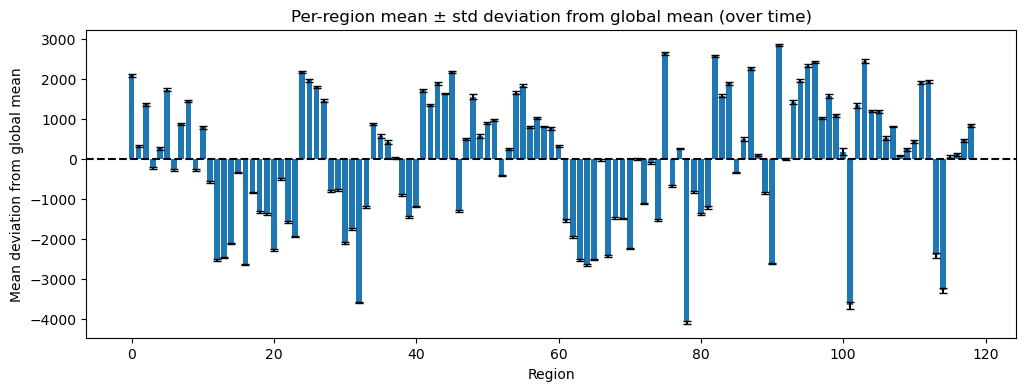

In [4]:
# compute deviations from the global mean time-series
global_mean = real_np.mean(axis=1)                # shape: (time,)
dev = real_np - global_mean[:, None]              # shape: (time, regions)

region_dev_mean = dev.mean(axis=0)
region_dev_std  = dev.std(axis=0)

plt.figure(figsize=(12,4))
plt.bar(np.arange(len(region_dev_mean)), region_dev_mean, yerr=region_dev_std, capsize=3)
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('Region')
plt.ylabel('Mean deviation from global mean')
plt.title('Per-region mean ± std deviation from global mean (over time)')
plt.show()

In [5]:
real_data_z = (real_np - real_np.mean(axis=0)) / (real_np.std(axis=0)  + 1e-8)

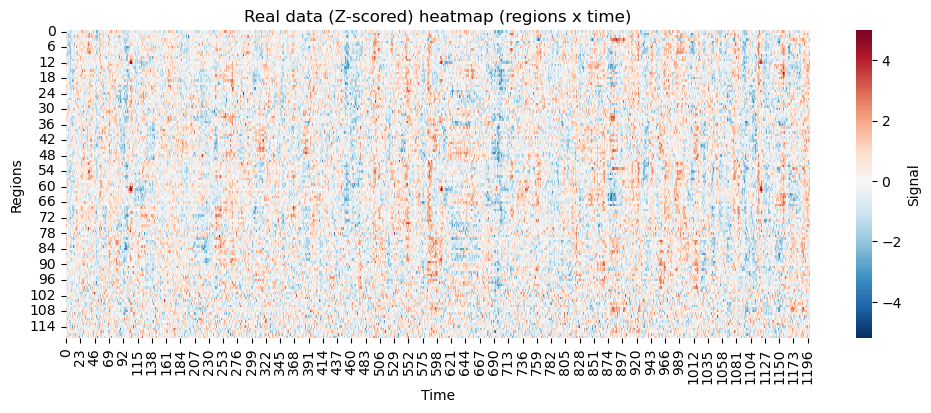

In [6]:
# Heatmap of real data (time x regions)
plt.figure(figsize=(12,4))
sns.heatmap(real_data_z.T, cmap='RdBu_r', center=0, cbar_kws={'label':'Signal'})
plt.title('Real data (Z-scored) heatmap (regions x time)')
plt.xlabel('Time')
plt.ylabel('Regions')
plt.show()

Hint of spatial coupling across regions.

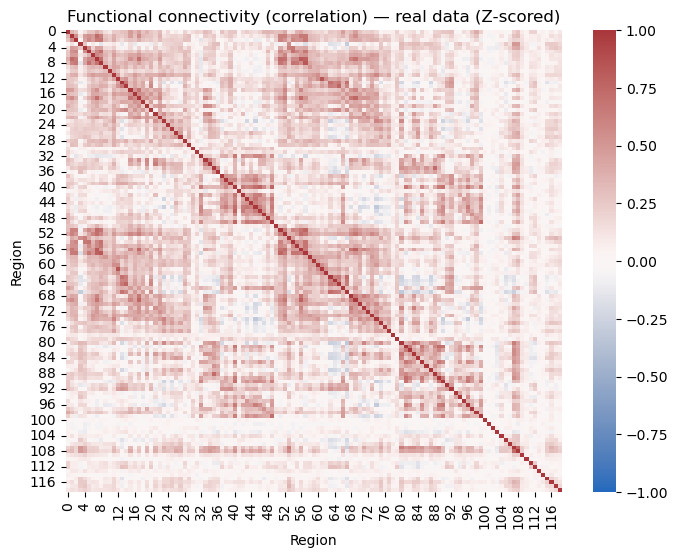

In [7]:
# Functional connectivity (correlation) across regions — use the full available time window
corr = np.corrcoef(real_data_z.T)  # regions x regions
plt.figure(figsize=(8,6))
sns.heatmap(corr, vmin=-1, vmax=1, cmap='vlag')  #, cbar_kws={'label':'Pearson r'})
plt.title('Functional connectivity (correlation) — real data (Z-scored)')
plt.xlabel('Region')
plt.ylabel('Region')
plt.show()

The functional connectivity matrix proves the existence of spatial coupling and high-dimensional cross-talk across several regions.

## Synthetic Dataset

### Mackey–Glass Equation

The Mackey–Glass delay differential equation (continuous form):

$$
\frac{dx(t)}{dt} = \beta \frac{x(t-\tau)}{1 + x(t-\tau)^n} - \gamma x(t)
$$

We use a discrete Euler approximation in the generator implemented in this notebook:

$$
x_{t+\Delta t} = x_t + \Delta t \left( \beta \frac{x_{t-\tau}}{1 + x_{t-\tau}^n} - \gamma x_t \right)
$$

Where: $\tau$ is the delay, $n$ the nonlinearity exponent, $\beta$ and $\gamma$ are parameters controlling feedback and decay, and $\Delta t$ is the integration step.

For the Mackey-Glass system generated with a physical delay $\tau$ and integration step $\Delta t$, the discrete delay index is calculated as $\tau/\Delta t$.


In [8]:
Time_steps = real_data.shape[0]
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()

synth_1D = np.asarray(X).squeeze()

print('synthetic data shape:', np.asarray(X).shape)

synthetic data shape: (1200, 1)


In [9]:
X_train = X[:1000,:]
X_test = X[1000:,:]
X_train.shape, X_test.shape

((1000, 1), (200, 1))

Input shape: (1000, 1)
Reservoir States shape: (1000, 500)


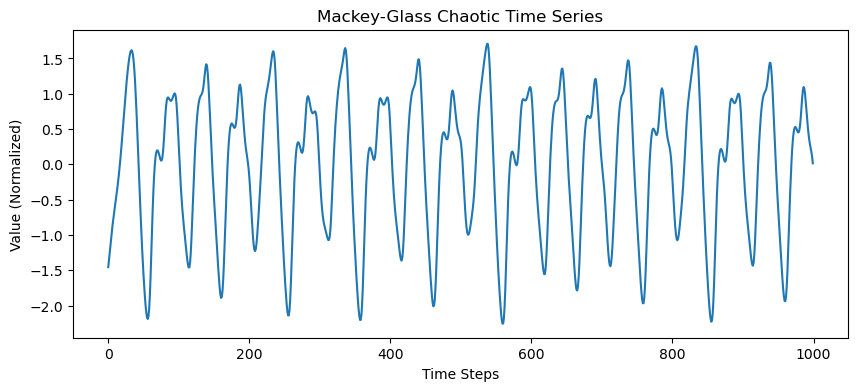

In [10]:
input_dim = X_train.shape[1]
reservoir_dim = 500
spectral_radius = 0.9
seed = 42

res = Reservoir(input_dim, reservoir_dim, spectral_radius, seed)

S_train = res.get_states(X_train)
S_test = res.get_states(X_test)

print(f"Input shape: {X_train.shape}")
print(f"Reservoir States shape: {S_train.shape}")

plt.figure(figsize=(10, 4))
plt.plot(X_train)
plt.title("Mackey-Glass Chaotic Time Series")
plt.xlabel("Time Steps")
plt.ylabel("Value (Normalized)")
plt.show()

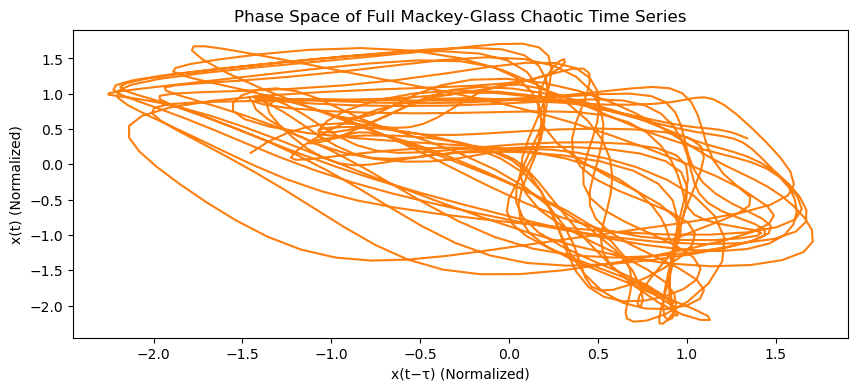

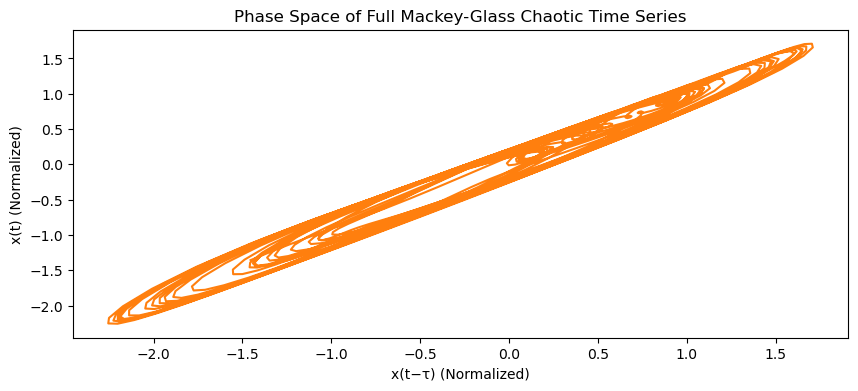

In [17]:
delay_steps = int(tau / delta_t)

plt.figure(figsize=(10, 4))
plt.plot(X[:-delay_steps], X[delay_steps:], color='C1')
plt.title("Phase Space of Full Mackey-Glass Chaotic Time Series")
plt.xlabel("x(t−τ) (Normalized)")
plt.ylabel("x(t) (Normalized)")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(X[:-1], X[1:], color='C1')
plt.title("Phase Space of Full Mackey-Glass Chaotic Time Series")
plt.xlabel("x(t−τ) (Normalized)")
plt.ylabel("x(t) (Normalized)")
plt.show()

In [12]:
synth_data = X.copy()
synth_1D = np.asarray(X).squeeze()

# Comparison

In [13]:
region_idx = np.random.choice(np.arange(real_data.shape[1]))
real_region_z = real_data_z[:, region_idx]

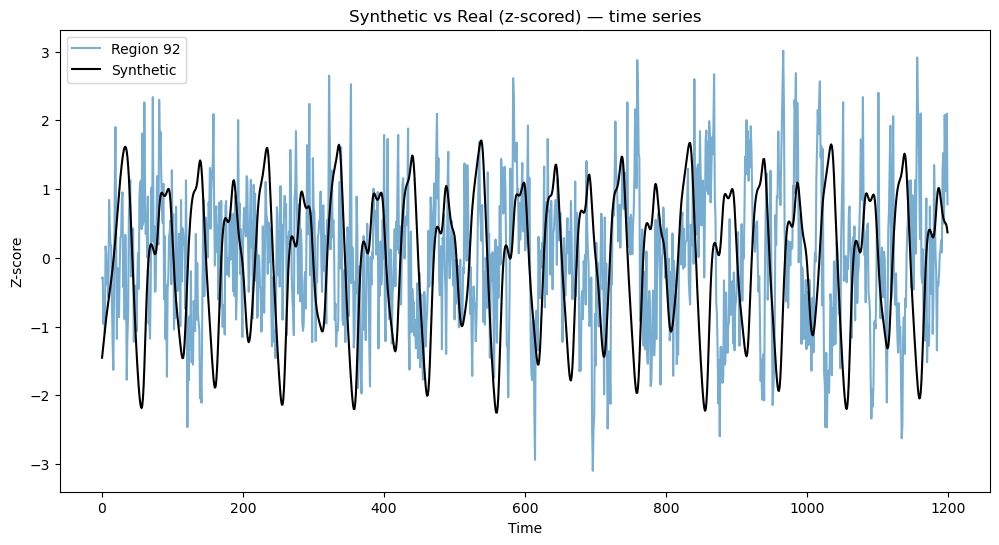

In [14]:
# Visualize stacked plots

plt.figure(figsize=(12,6))
plt.plot(real_region_z, alpha=0.6, label=f'Region {region_idx}')
plt.plot(synth_1D, alpha=1, label='Synthetic', color='black')
plt.legend()
plt.title('Synthetic vs Real (z-scored) — time series')
plt.xlabel('Time')
plt.ylabel('Z-score')
plt.show()

From the overlay of the two datasets we visualize whether with the selected paramters the MG dataset, despite being very different, somewhat resembles the variability of the real datatset, in the hope that a good performance on the synthetic dataset can lead to a decent performance on the brain data. 